# 2. Hyperparameter tuning

This notebook examines UMAP and hdbscan hyperparameters. The goal in using these algorithms is to identify clusters of words that substantially represent the same "concept." Different parameters are tried, checked for coherence, and manually inspected.

Input:\
`data/ANES_2016_CLEANED.txt` : a tab-seperated file with `_clean` fields for every text response. 

Output:\
No output file. However, hyperparameters determined to result in coherent word clusters are retained for use in `3_NetworkExtraction.ipynb`. The replicabled parameters used are:
* seed = 42 (used as `random_state` in `UMAP()` function
* n_components = 25  (UMAP)
* min_cluster_size = 6 (hdbscan)
* min_samples = 7  (hdbscan)


In [1]:
# helpful packages
import pandas as pd
import itertools as it
import numpy as np

# language models
import spacy
from spacy.tokens import Doc
nlp = spacy.load('en_core_web_trf')

# language clustering
from gensim.models import KeyedVectors
import umap
import hdbscan
from sklearn.metrics.pairwise import cosine_similarity

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# visualization
import matplotlib.pyplot as plt

# Load cleaned data

In [2]:
# read cleaned data
df = pd.read_csv('data/ANES_2016_CLEANED.txt', sep='\t')

print(f'Data includes {len(df)} observations on {len(df.columns)} variables.')
print(f'\nRecorded variables are:\n{", ".join(df.columns)}')

Data includes 4270 observations on 30 variables.

Recorded variables are:
V160001, V160001_orig, age, female, education, leftright, politicalinterest, politicalparticipation, TIPI_extraversion, TIPI_agreeableness, TIPI_conscientiousness, TIPI_emotionalstability, TIPI_openness, V161069, V161072, V161075, V161078, V161098, V161101, V161104, V161106, party_id, V161069_clean, V161072_clean, V161075_clean, V161078_clean, V161098_clean, V161101_clean, V161104_clean, V161106_clean


In [3]:
# Questions with free-response answers. 
text_qs = ['V161069', # PRE: Text- What is it that R likes about Democratic Pres cand
           'V161072', # PRE: Text- What is it that R dislikes about Democratic Pres cand
           'V161075', # PRE: Text- What is it that R likes about Republican Pres cand
           'V161078', # PRE: Text- What is it that R dislikes about Republican Pres cand
           'V161098', # PRE: Text- What does R like about Democratic party
           'V161101', # PRE: Text- What does R dislike about the Democratic party
           'V161104', # PRE: Text- What does R like about Republican party
           'V161106'  # PRE: Text- What does R dislike about the Republican party
          ]

In [4]:
# create spacy docs of each response
for q in text_qs:
    print(f'  Processing question {q}')
    df[f'{q}_doc'] = df[f'{q}_clean'].fillna('').apply(lambda x: nlp(x))
    
print('All text converted to SpaCy.')

  Processing question V161069
  Processing question V161072
  Processing question V161075
  Processing question V161078
  Processing question V161101
  Processing question V161104
  Processing question V161106
All text converted to SpaCy.


# Word (node) extraction

In [5]:
# keep as nodes word that are these parts of speech:
keep_pos = ['ADJ', 'ADV', 'NOUN', 'PROPN', 'VERB']


raw_nodes = list()

for q in text_qs:
    docs = df[f'{q}_doc']

    for doc in docs:
        # nodes to keep (unclustered)
        for token in doc:
            if token.pos_ in keep_pos and token.lemma_ not in raw_nodes:
                raw_nodes.append(token.lemma_)
                
print(f'{len(raw_nodes)} words initially retained as nodes across all responses')

8760 words initially retained as nodes across all responses


### Convert to embeddings

In [6]:
# embeddings model
model = KeyedVectors.load_word2vec_format('../GoogleNews-vectors-negative300.bin', binary=True)

vecs = list() # embeddings for in-vocab words
kept = list() # words that have an embedding in vecs 
skipped = list() # out of vocab (dropped from analysis)

for word in raw_nodes:
    try:
        vector = model[word]
        vecs.append(vector) # save vector
        kept.append(word) # save word
    except:
        skipped.append(word) # out of vocab (after spell check correction)
    
word_embeddings = np.vstack(vecs)

w, n = word_embeddings.shape
print(f'{w} words embedded into {n}-dimensions.')
print(f'{len(skipped)} words dropped as out of vocabulary.')

6014 words embedded into 300-dimensions.
2746 words dropped as out of vocabulary.


# Cluster word embeddings using UMap + hdbscan

In [7]:
def calc_coherence(words, word_embeddings, cluster_labels, model):
    clusters = np.arange(0, max(cluster_labels), step=1)
    coherence_scores = np.zeros(len(clusters))

    for cluster_id in clusters:
        
        # get indices belonging to this cluster
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_words = [words[i] for i in indices]
        cluster_vecs = word_embeddings[indices]

        if len(cluster_vecs) < 2:
            coherence_scores[cluster_id] = None  # can't compute pairwise for 1 word
            continue

        # mean pairwise cosine similarity
        sim_matrix = cosine_similarity(cluster_vecs)
        # upper triangle only (exclude self-similarity on diagonal)
        upper = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
        coherence_scores[cluster_id] = upper.mean()

    return coherence_scores

In [8]:
def run_clustering(n_components, min_cluster_size, min_samples, word_embeddings):
    
    # reduce dimensionality
    reducer = umap.UMAP(n_components = n_components, random_state=42, n_jobs=1) 
    embedding = reducer.fit_transform(word_embeddings)

    # cluster
    clusterer = hdbscan.HDBSCAN(min_cluster_size = min_cluster_size, 
                                min_samples = min_samples, 
                                prediction_data = True,
                                approx_min_span_tree=False)

    cluster_labels = clusterer.fit_predict(embedding)
    
    return cluster_labels

In [9]:
def check_hyper(kept, word_embeddings, model):
    n_components_range = np.arange(5, 50, 5)
    min_cluster_range = np.arange(2, 10, 1)
    min_samples_range = np.arange(1, 10, 1)
    
    hypes = list()
    scores = list()
    
    for n_comp, min_clust, min_samp in it.product(n_components_range, min_cluster_range, min_samples_range):
        cluster_labels = run_clustering(n_comp, min_clust, min_samp, word_embeddings)    
        coherence_scores = calc_coherence(kept, word_embeddings, cluster_labels, model)
        
        # count number of clusters. Note: words assigned to "-1" (no cluster) retained as unique words
        n_clusters = list(cluster_labels).count(-1) + max(cluster_labels) + 1 # 0-indexed
        
        # save hyper parameters and number of clusters
        hypes.append([n_comp, min_clust, min_samp, n_clusters])
        
        # save coherence scores
        scores.append(coherence_scores)
        
    return hypes, scores

In [10]:
hypes, scores = check_hyper(kept, word_embeddings, model) # started 12:25

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [11]:
y = list()

for h, s in zip(hypes, scores):
    score = np.mean(s) * h[-1] * min(s)
    y.append(score)

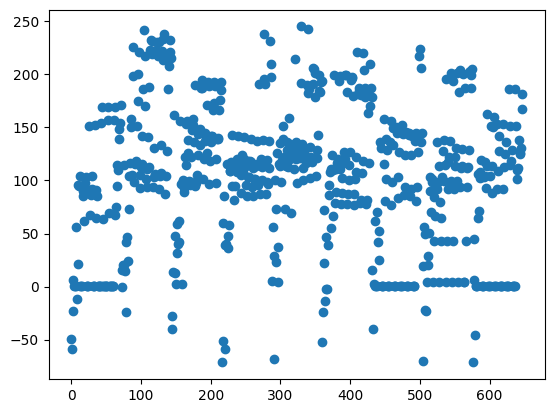

In [12]:
plt.scatter(range(len(hypes)), y)
plt.show()

In [13]:
idx = np.where(np.array(y) == max(y))[0]

for val in idx:
    print(hypes[val], y[val])

[25, 6, 7, 3981] 245.18657907879725


# Manual evaluation

In [14]:
# hyperparameters
n_components = 25 
min_cluster_size = 6
min_samples = 7 

cluster_labels = run_clustering(n_components, min_cluster_size, min_samples, word_embeddings)    
coherence_scores = calc_coherence(kept, word_embeddings, cluster_labels, model)
        
# count number of clusters. Note: words assigned to "-1" (no cluster) retained as unique words
n_clusters = list(cluster_labels).count(-1) + max(cluster_labels) + 1 # 0-indexed

print(f'{n_clusters} found') #3853 found


3981 found


In [15]:
# Dict 1: {num : [words]} 
clust_words = dict() 

for word, label in zip(kept, cluster_labels):
    clust_words.setdefault(label, set())
    clust_words[label].add(word)

In [16]:
clust_words[0]

{'dependance',
 'dependancy',
 'dependency',
 'dependent',
 'reliance',
 'reliant',
 'rely'}

In [18]:
clust_words[2]

{'breakup',
 'disparity',
 'divide',
 'divided',
 'gap',
 'separation',
 'split',
 'splitting'}

In [21]:
clust_words[6]

{'baron',
 'billionaire',
 'billionare',
 'businesman',
 'businessman',
 'empire',
 'entrepeneur',
 'entrepreneur',
 'fortune',
 'millionaire',
 'mogul',
 'oligarch',
 'salesman',
 'tycoon'}